# The thematic heatmap

Built from [`THEMATIC_HEATMAP.md`](../THEMATIC_HEATMAP.md), the complete design specification for this visual.

This notebook loads the artifacts already computed by [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp) (Phase 5: `lda_topics.parquet`) and the dates already fixed by [`hansard-pm-extraction`](https://github.com/RedaAllab/hansard-pm-extraction) (`PHASE0_SCOPING.md`, carried into `pm_tenures.parquet` and `event_study.py`), without re-running `build_lda_topics.py` or eyeballing a single date. It produces the 4 images in `portfolio/02_topic_heatmap/assets/`:

1. `banner.png`
2. `heatmap_main.png`: the 13 topics x month heatmap
3. `small_multiples.png`: each topic on its own
4. `covid_zoom.png`: the 3 Covid topics, zoomed in

Prerequisite: `hansard-pm-nlp` cloned as a sibling directory (`../hansard-pm-nlp`) or `HANSARD_PM_NLP_DIR` pointing at it, see this repo's root README.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import topic_heatmap as viz
from hansard_pm_portfolio.viz.common import plot_banner, save

ASSETS_DIR = Path("../portfolio/02_topic_heatmap/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. README banner

In [2]:
fig = plot_banner("The thematic heatmap", "hansard-pm-portfolio, project 02")
save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Load the topics, crisis windows and transition dates

- `lda_topics.parquet` (Phase 5): 296 documents (PM x sitting), K=14 topics, all 4 PMs (Truss included, unlike Phase 6).
- The T0+T1 merge (Ukraine/Russia, near duplicates) is carried over unchanged from `phase5_lda_report.md`, see `data_access.merge_overlapping_topics()`.
- The 13 plain language labels (`data_access.TOPIC_LABELS`) are new editorial work for this project: neither `phase5_lda_report.md` nor the live dashboard offer any (the dashboard only shows algorithmic labels like "T2: hs, project, rail"). Written from the report's own keyword lists, traceability kept as comments in `data_access/_shared.py`.
- Crisis windows and tenure dates come from `data_access.CRISIS_WINDOWS` (ported from `event_study.py`) and `load_pm_tenures()` (`data/input/pm_tenures.parquet`), verified to match `PHASE0_SCOPING.md` exactly.

In [3]:
topics = da.load_topic_weights()
tenures = da.load_pm_tenures()
monthly = da.monthly_topic_matrix(topics)
print(f"{len(topics)} documents, {monthly.shape[0]} months, {monthly.shape[1]} topics")
tenures

296 documents, 77 months, 13 topics


,pm_name,pm_party,member_id,tenure_start,tenure_end
0,Boris Johnson,Conservative,1423,2019-07-24,2022-09-06
1,Liz Truss,Conservative,4097,2022-09-06,2022-10-25
2,Rishi Sunak,Conservative,4483,2022-10-25,2024-07-05
3,Keir Starmer,Labour,4514,2024-07-05,2026-07-20


## 2. The main heatmap

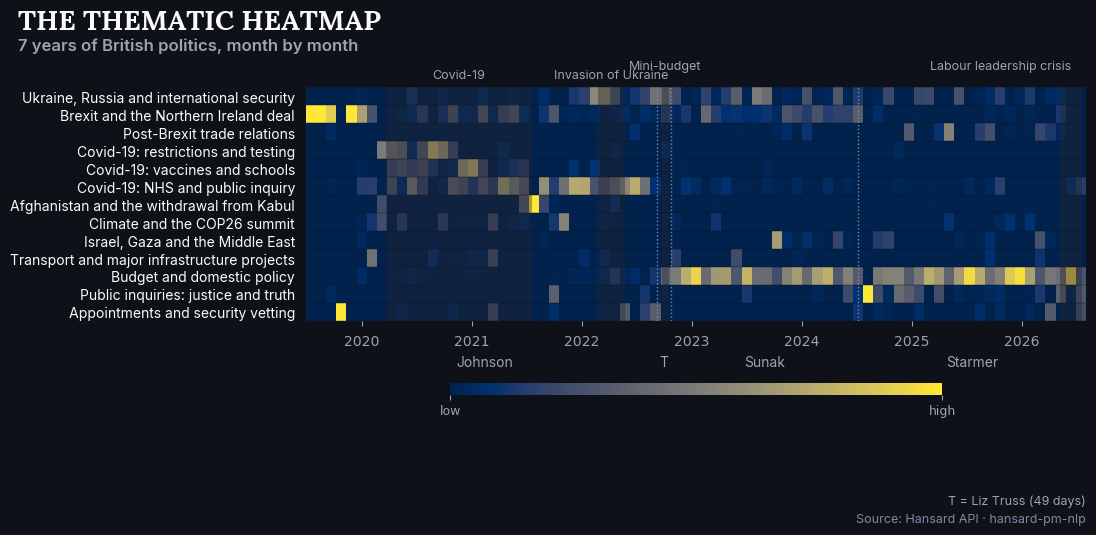

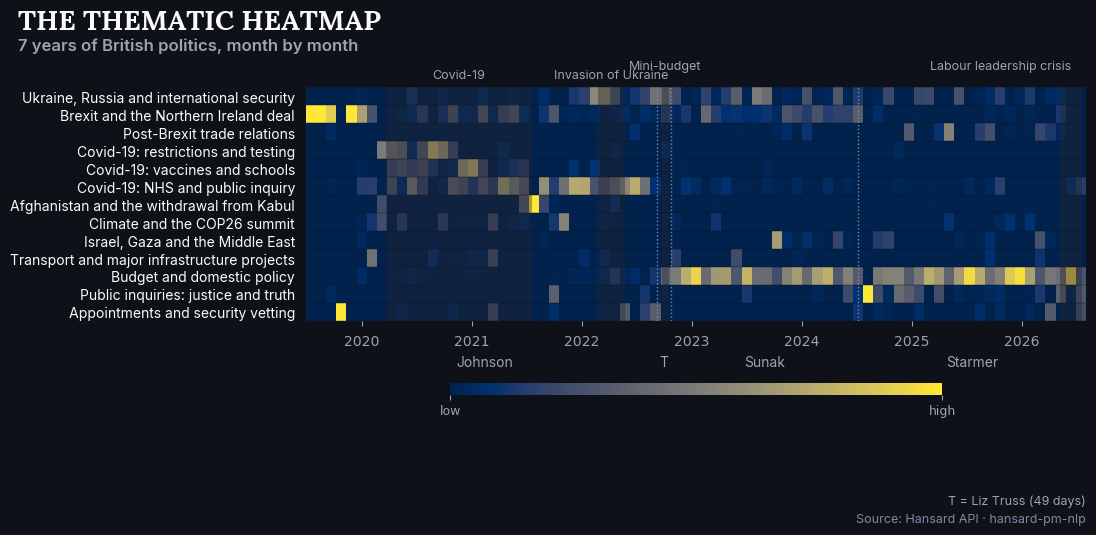

In [4]:
fig = viz.plot_topic_heatmap(monthly, tenures)
save(fig, ASSETS_DIR / "heatmap_main.png")
fig

## 3. Each topic on its own

Small multiples rather than a 13 color overlapping streamgraph. app.py (the live dashboard) already tried both for its own Topics tab and documented why small multiples win at this scale (a 13 color legend stops being readable, and a stacked area hides whether a topic is rising or falling). Reused as is rather than retested.

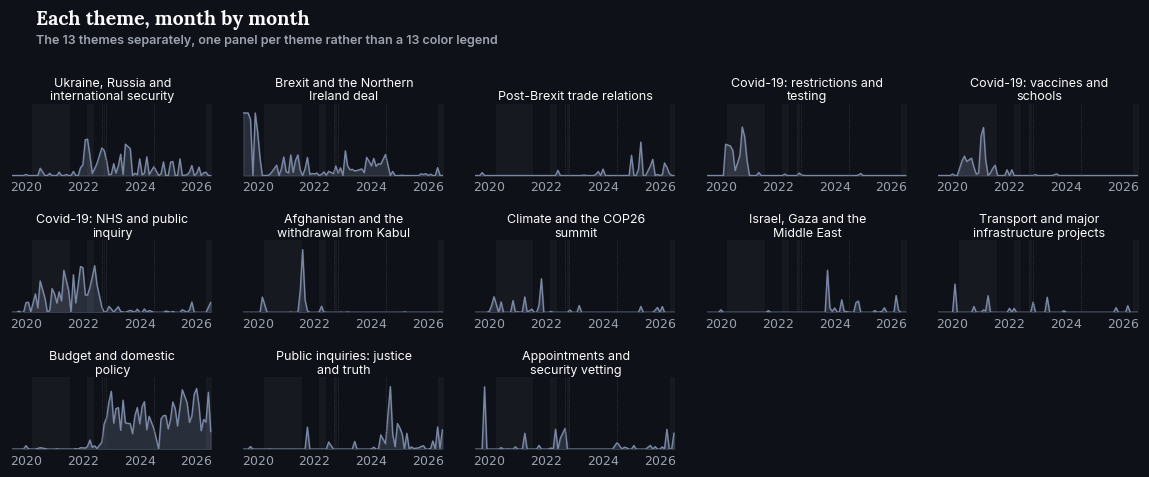

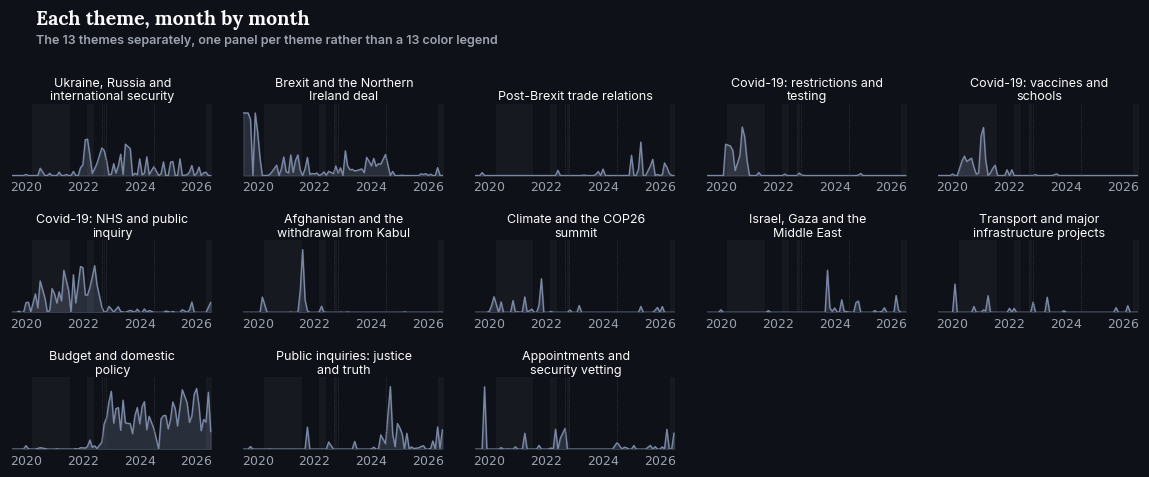

In [5]:
fig = viz.plot_topic_small_multiples(monthly, tenures)
save(fig, ASSETS_DIR / "small_multiples.png")
fig

## 4. Covid-19: why 3 topics, not 1

Unlike Ukraine/Russia (T0+T1), the 3 Covid topics were never merged. That is not an oversight: app.py (the live dashboard's Topics tab) already documents why. These 3 topics track distinct sub-phases of the same crisis (restrictions/testing, vaccines/schools, NHS staff/inquiry), not a duplicate like T0/T1.

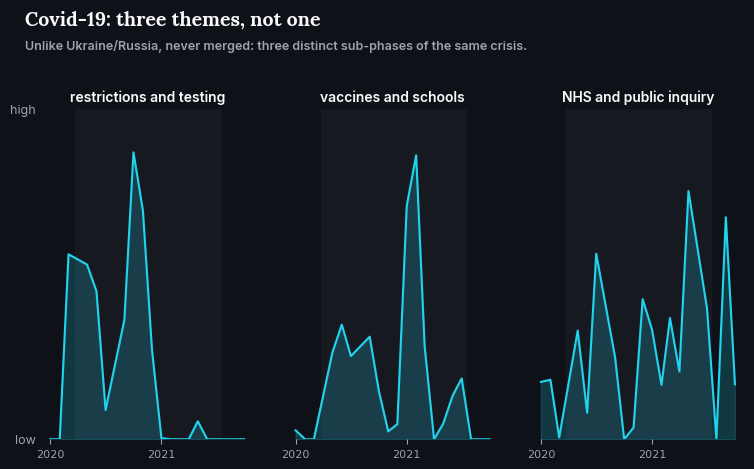

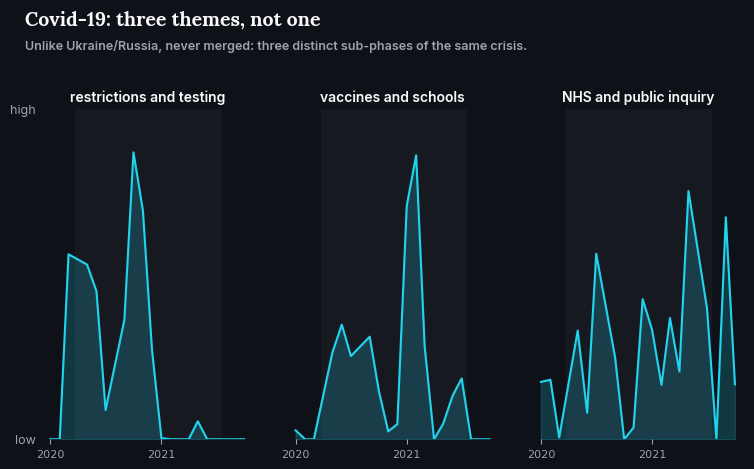

In [6]:
fig = viz.plot_covid_zoom(monthly)
save(fig, ASSETS_DIR / "covid_zoom.png")
fig

## Links

- Full specification: [`THEMATIC_HEATMAP.md`](../THEMATIC_HEATMAP.md)
- LDA model source report: [`phase5_lda_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase5_lda_report.md) (in `hansard-pm-nlp`)
- LDA vs BERTopic comparison: [`phase5_topic_comparison_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase5_topic_comparison_report.md)
- Interactive dashboard: see `hansard-pm-nlp`'s root README
- This project's README: [`portfolio/02_topic_heatmap/README.md`](../portfolio/02_topic_heatmap/README.md)